# STAG 连续时序 Conv-SNN 训练

本 notebook 负责参数设置、数据集构建、训练过程、每轮测试评估、测试集早停、模型保存和结果可视化。底层函数均定义在清晰注释的 `.py` 文件中。

> **实验方法提醒**：按照当前要求，官方测试集每个 epoch 都参与评估，并用于早停和选择最佳模型。因此这里的测试集实际承担验证集角色，最高测试准确率存在模型选择偏倚，不是严格独立的最终泛化结果。该事实会写入 `config.json` 和 `summary.json`。

In [1]:
%matplotlib inline

from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from spikingjelly.activation_based import functional

CODE_DIR = next(
    path for path in (Path.cwd(), Path.cwd() / "code")
    if (path / "stag_data.py").is_file()
)
PROJECT_ROOT = CODE_DIR.parent
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from snn_model import ConvSNNClassifier, count_trainable_parameters
from stag_data import (
    build_window_index,
    load_stag_metadata,
    save_class_mapping,
    summarize_window_index,
)
from stag_dataset import STAGSequenceDataset, compute_class_weights
from train_utils import (
    EarlyStopping,
    build_history_row,
    evaluate,
    load_checkpoint,
    prepare_output_directory,
    recommended_device,
    save_checkpoint,
    save_history_csv,
    save_json,
    seed_worker,
    set_random_seed,
    train_one_epoch,
)
from visualization import (
    plot_class_distribution,
    plot_confusion_matrix,
    plot_prediction_examples,
    plot_tactile_sequence,
    plot_training_curves,
)

print(f"PyTorch：{torch.__version__}")
print(f"CUDA 可用：{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU：{torch.cuda.get_device_name(0)}")

PyTorch：2.8.0+cu128
CUDA 可用：True
GPU：NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Noto Sans CJK JP',
    'Noto Sans CJK SC',
    'WenQuanYi Zen Hei'
]

plt.rcParams['axes.unicode_minus'] = False

## 1. 全部实验参数

默认 `RUN_TRAINING=False`。保持该值时，notebook 只会读取真实数据并完成一个批次的模型前向检查，不会进入训练循环。

In [ ]:
# ===== 安全开关 =====
RUN_TRAINING = True

# ===== 路径与复现 =====
ZIP_PATH = PROJECT_ROOT / "stag_data" / "classification_lite.zip"
OUTPUT_ROOT = CODE_DIR / "outputs"
EXPERIMENT_NAME = "conv_snn_interaction_l16_s8"
SEED = 42

# ===== 数据窗口 =====
WINDOW_SIZE = 16
STRIDE = 8
WINDOW_MODE = "interaction"       # 可改为 "stable"
MIN_VALID_RATIO = 0.5             # stable 模式会自动要求 1.0
BAD_PRESSURE_THRESHOLD = 950.0
GAP_FACTOR = 2.5
PRESSURE_MIN = 500.0
PRESSURE_MAX = 650.0

# ===== DataLoader =====
BATCH_SIZE = 16
NUM_WORKERS = 0                   # Windows 下避免复制完整 pressure 数组
PIN_MEMORY = torch.cuda.is_available()

# ===== 模型与训练 =====
MODEL_CHANNELS = (16, 32, 64)
TAU = 2.0
MAX_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
EARLY_STOPPING_PATIENCE = 10
USE_CLASS_WEIGHTS = True

DEVICE = recommended_device()
print(f"运行设备：{DEVICE}")
print(f"正式训练开关：{RUN_TRAINING}")

运行设备：cuda
正式训练开关：True


## 2. 读取数据并构建窗口清单

窗口清单只保存索引，不复制重叠压力帧。过滤 `empty_hand` 后，原始 `objectId=1..26` 会映射成模型标签 `0..25`。

In [4]:
set_random_seed(SEED)
metadata = load_stag_metadata(ZIP_PATH)
window_index = build_window_index(
    metadata,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    mode=WINDOW_MODE,
    min_valid_ratio=MIN_VALID_RATIO,
    include_empty_hand=False,
    bad_pressure_threshold=BAD_PRESSURE_THRESHOLD,
    gap_factor=GAP_FACTOR,
)
train_manifest = window_index.split_manifest("train")
test_manifest = window_index.split_manifest("test")
class_names = window_index.class_names
num_classes = len(class_names)

display(summarize_window_index(window_index))
print(f"模型类别数：{num_classes}")
print(f"训练 recording：{train_manifest['recording_id'].nunique()}")
print(f"测试 recording：{test_manifest['recording_id'].nunique()}")
print(f"recording 是否无交集：{set(train_manifest['recording_id']).isdisjoint(set(test_manifest['recording_id']))}")

if WINDOW_MODE == "stable":
    missing_by_split = {
        split: sorted(set(range(num_classes)) - set(group["label"]))
        for split, group in window_index.manifest.groupby("split")
    }
    print(f"稳定模式各划分缺失标签：{missing_by_split}")

,split,windows,recordings,classes,mean_valid_ratio
0,train,8315,52,26,0.741221
1,test,3352,26,26,0.815577


模型类别数：26
训练 recording：52
测试 recording：26
recording 是否无交集：True


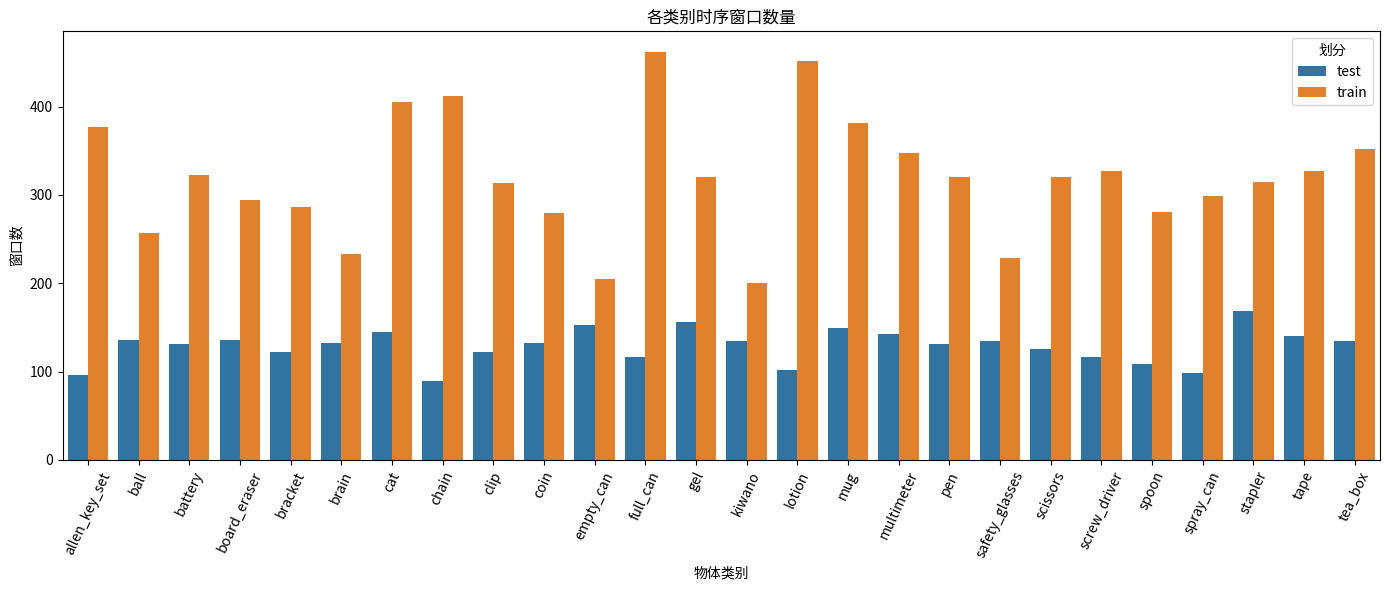

,split,split_id,batch_id,batch_name,recording_id,recording_name,start_offset,length,original_object_id,label,object_name,valid_ratio,start_frame,end_frame,start_timestamp,end_timestamp
0,train,0,1,001,28,028-mug,8,16,16,15,mug,0.7500,8,23,1.089062,3.137179
1,train,0,1,001,28,028-mug,16,16,16,15,mug,0.5625,16,31,2.182125,4.227242
2,train,0,1,001,28,028-mug,24,16,16,15,mug,0.5625,24,39,3.273187,5.333305
3,train,0,1,001,28,028-mug,32,16,16,15,mug,0.8750,32,47,4.363250,6.422367
4,train,0,1,001,28,028-mug,40,16,16,15,mug,0.6250,40,55,5.469313,7.514430


In [5]:
plot_class_distribution(window_index.manifest, class_names)
plt.show()

display(train_manifest.head())

## 3. Dataset 与 DataLoader

模型收到的输入形状为 `[B, 16, 1, 32, 32]`。无效矩阵位置在归一化后会被掩码清零。

x：(16, 16, 1, 32, 32), torch.float32
y：(16,), 范围 0~25
归一化范围：0.000~0.967


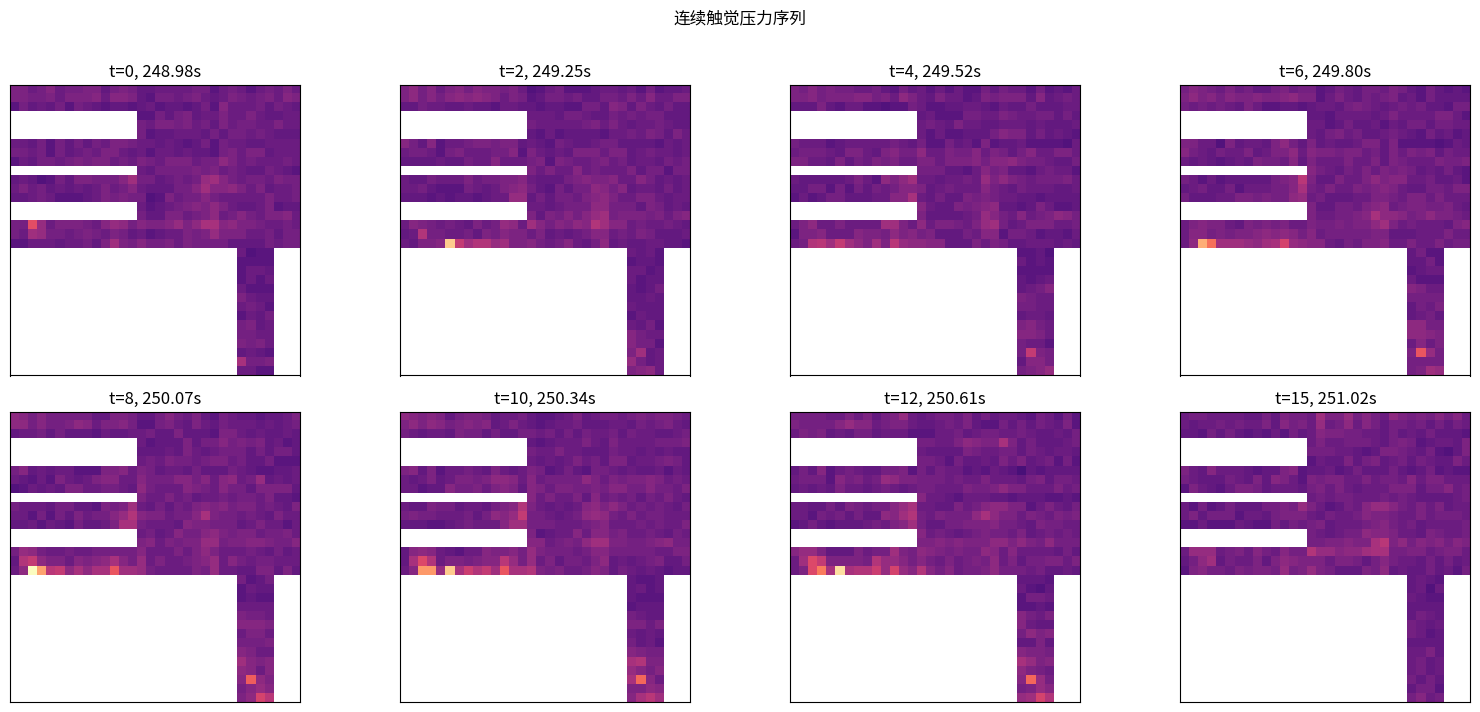

In [6]:
train_dataset = STAGSequenceDataset(
    metadata,
    train_manifest,
    window_index.recording_indices,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
)
test_dataset = STAGSequenceDataset(
    metadata,
    test_manifest,
    window_index.recording_indices,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
)

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    generator=generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

sample_batch = next(iter(train_loader))
print(f"x：{tuple(sample_batch['x'].shape)}, {sample_batch['x'].dtype}")
print(f"y：{tuple(sample_batch['y'].shape)}, 范围 {sample_batch['y'].min().item()}~{sample_batch['y'].max().item()}")
print(f"归一化范围：{sample_batch['x'].min().item():.3f}~{sample_batch['x'].max().item():.3f}")

plot_tactile_sequence(
    sample_batch["x"][0],
    timestamps=sample_batch["timestamps"][0],
    sensor_mask=metadata.sensor_mask,
)
plt.show()

## 4. 建立 Conv-SNN 并完成安全前向检查

这一节即使 `RUN_TRAINING=False` 也会运行，但不调用反向传播和优化器。检查后立即重置所有 LIF 膜电位。

In [7]:
model = ConvSNNClassifier(
    num_classes=num_classes,
    in_channels=1,
    channels=MODEL_CHANNELS,
    tau=TAU,
).to(DEVICE)

with torch.no_grad():
    try:
        smoke_logits = model(sample_batch["x"][:2].to(DEVICE))
    finally:
        functional.reset_net(model)

print(model)
print(f"可训练参数量：{count_trainable_parameters(model):,}")
print(f"真实批次前向输出：{tuple(smoke_logits.shape)}")
assert tuple(smoke_logits.shape) == (2, num_classes)

ConvSNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=m)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, step_mode=m)
    (2): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=m)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=m)
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, step_mode=m)
    (6): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=m)
    (8): Con

## 5. 正式训练、每轮测试、早停与保存

只有把 `RUN_TRAINING` 改为 `True` 才会执行本节。最佳模型按测试准确率选择；准确率相同时选择测试损失更低的 epoch。

In [ ]:
history = []
output_dir = None
best_test_result = None
training_finished = False

experiment_config = {
    "experiment_name": EXPERIMENT_NAME,
    "zip_path": str(ZIP_PATH),
    "seed": SEED,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "window_mode": WINDOW_MODE,
    "min_valid_ratio": MIN_VALID_RATIO,
    "bad_pressure_threshold": BAD_PRESSURE_THRESHOLD,
    "gap_factor": GAP_FACTOR,
    "pressure_min": PRESSURE_MIN,
    "pressure_max": PRESSURE_MAX,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "model_channels": list(MODEL_CHANNELS),
    "tau": TAU,
    "max_epochs": MAX_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_metric": "test_accuracy",
    "tie_breaker": "lower_test_loss",
    "use_class_weights": USE_CLASS_WEIGHTS,
    "test_set_used_for_early_stopping": True,
    "methodological_warning": (
        "官方测试集每个 epoch 都参与早停和最佳模型选择，"
        "因此最终测试结果存在模型选择偏倚。"
    ),
}

if not RUN_TRAINING:
    print("RUN_TRAINING=False：已安全跳过正式训练、文件写入和 epoch 测试。")
else:
    output_dir = prepare_output_directory(OUTPUT_ROOT, EXPERIMENT_NAME)
    save_json(output_dir / "config.json", experiment_config)
    save_class_mapping(
        output_dir / "class_mapping.json",
        class_names,
        window_index.original_object_id_to_label,
    )
    train_manifest.to_csv(output_dir / "train_windows.csv", index=False, encoding="utf-8-sig")
    test_manifest.to_csv(output_dir / "test_windows.csv", index=False, encoding="utf-8-sig")

    class_weights = (
        compute_class_weights(train_manifest, num_classes).to(DEVICE)
        if USE_CLASS_WEIGHTS
        else None
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
    )
    early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
    training_start = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        train_result = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
            num_classes,
            grad_clip=GRAD_CLIP,
        )
        # 按当前实验要求，官方测试集在每个 epoch 后用于模型选择。
        test_result = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
            num_classes,
        )
        row = build_history_row(
            epoch,
            current_lr,
            train_result,
            test_result,
        )
        history.append(row)
        improved, should_stop = early_stopping.step(
            test_result.accuracy,
            test_result.loss,
            epoch,
        )
        scheduler.step()

        save_checkpoint(
            output_dir / "last_model.pt",
            model,
            optimizer,
            scheduler,
            epoch,
            class_names,
            model.get_config(),
            row,
            early_stopping,
            experiment_config,
        )
        if improved:
            save_checkpoint(
                output_dir / "best_model.pt",
                model,
                optimizer,
                scheduler,
                epoch,
                class_names,
                model.get_config(),
                row,
                early_stopping,
                experiment_config,
            )
        save_history_csv(output_dir / "history.csv", history)

        marker = "（已保存最佳模型）" if improved else ""
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_result.loss:.4f}, acc={train_result.accuracy:.4f} | "
            f"test loss={test_result.loss:.4f}, acc={test_result.accuracy:.4f}, "
            f"macro-F1={test_result.macro_f1:.4f} {marker}"
        )
        if should_stop:
            print(f"连续 {EARLY_STOPPING_PATIENCE} 个 epoch 未改进，提前停止。")
            break

    checkpoint = load_checkpoint(
        output_dir / "best_model.pt",
        model,
        map_location=DEVICE,
    )
    best_test_result = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
        num_classes,
    )
    elapsed_seconds = time.time() - training_start
    summary = {
        "best_epoch": checkpoint["epoch"],
        "best_test_loss": best_test_result.loss,
        "best_test_accuracy": best_test_result.accuracy,
        "best_test_macro_f1": best_test_result.macro_f1,
        "epochs_completed": len(history),
        "early_stopped": len(history) < MAX_EPOCHS,
        "elapsed_seconds": elapsed_seconds,
        "train_windows": len(train_manifest),
        "test_windows": len(test_manifest),
        "test_set_used_for_early_stopping": True,
        "methodological_warning": experiment_config["methodological_warning"],
    }
    save_json(output_dir / "summary.json", summary)
    plot_training_curves(
        history,
        best_epoch=checkpoint["epoch"],
        save_path=output_dir / "training_curves.png",
    )
    plt.show()
    plot_confusion_matrix(
        best_test_result.confusion_matrix,
        class_names,
        normalize=True,
        save_path=output_dir / "confusion_matrix.png",
    )
    plt.show()
    display(pd.DataFrame([summary]))
    training_finished = True

训练:   0%|          | 0/520 [00:00<?, ?it/s]

评估:   0%|          | 0/210 [00:00<?, ?it/s]

Epoch 001 | train loss=3.1681, acc=0.0992 | test loss=3.2151, acc=0.0805, macro-F1=0.0247 （已保存最佳模型）


训练:   0%|          | 0/520 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fdea1ca9080>
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fdea1ca9080>
Traceback (most recent call last):
  File "/root/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/root/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1610, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/root/miniconda3/lib/python3.12/threading.py", line 1144, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
Traceback (most recent call last):
  File "/root/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/root/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():Exception ign

## 6. 最佳模型预测示例

仅在正式训练完成后执行。展示每个窗口的中间触觉帧、真实类别和预测类别。

In [ ]:
if not training_finished:
    print("尚未执行正式训练，因此没有最佳模型预测示例。")
else:
    prediction_batch = next(iter(test_loader))
    with torch.no_grad():
        try:
            prediction_logits = model(prediction_batch["x"].to(DEVICE))
        finally:
            functional.reset_net(model)
    predictions = prediction_logits.argmax(dim=1).cpu().numpy()
    targets = prediction_batch["y"].numpy()
    plot_prediction_examples(
        prediction_batch["x"],
        targets,
        predictions,
        class_names,
        metadata.sensor_mask,
    )
    plt.show()
    print(f"实验文件已保存到：{output_dir}")